In [36]:
import numpy as np
import matplotlib.pyplot as plt
import time

In [37]:


year = np.array([2018, 2016, 2015, 2016, 2021, 2006, 2021, 2014, 2019, 2012, 2011, 2014, 2017])
speed = np.array([159, 138, 140, 142, 179, 138, 166, 140, 151, 126, 124, 137, 138])


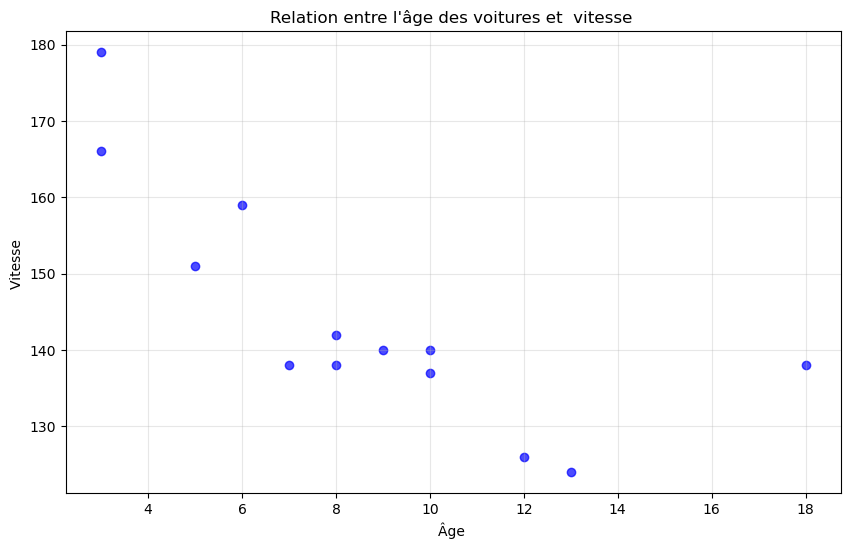

In [38]:
current_year = 2024
age = current_year - year

# 2. Tracer le graphique
plt.figure(figsize=(10, 6))
plt.scatter(age, speed, color='blue', alpha=0.7)
plt.xlabel('Âge ')
plt.ylabel('Vitesse ')
plt.title('Relation entre l\'âge des voitures et  vitesse ')
plt.grid(True, alpha=0.3)
plt.show()

In [39]:
import numpy as np

year = np.array([2018, 2016, 2015, 2016, 2021, 2006, 2021, 2014, 2019, 2012, 2011, 2014, 2017])
speed = np.array([159, 138, 140, 142, 179, 138, 166, 140, 151, 126, 124, 137, 138])

current_year = 2024
x = (current_year - year).astype(float)
y = speed.astype(float)


x_reshaped = x.reshape(-1, 1)
ones = np.ones((len(x),1))
X = np.hstack((ones, x_reshaped))
#q2
np.random.seed(42)
theta = np.random.randn(2, 1)

#q3


start_time = time.time()

y_pred_for = np.zeros(len(X))
for i in range(len(X)):
    y_pred_for[i] = theta[0] * X[i, 0] + theta[1] * X[i, 1]

end_time = time.time()
time_for = end_time - start_time

print("Prédictions (boucle for):", y_pred_for)
print("Temps boucle for:", time_for)

Prédictions (boucle for): [-0.33287165 -0.60940026 -0.74766456 -0.60940026  0.08192125 -1.99204327
  0.08192125 -0.88592886 -0.19460735 -1.16245746 -1.30072176 -0.88592886
 -0.47113596]
Temps boucle for: 0.0005180835723876953


C:\Users\chikh\AppData\Local\Temp\ipykernel_4544\3950200254.py:25: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  y_pred_for[i] = theta[0] * X[i, 0] + theta[1] * X[i, 1]


In [40]:
start_time = time.time()

y_pred_vectorized = X.dot(theta).flatten()

end_time = time.time()
time_vectorized = end_time - start_time

print("Prédictions (vectorisé):", y_pred_vectorized)
print("Temps vectorisé:", time_vectorized)

print("Ratio:", time_for/time_vectorized)
print("Résultats identiques?", np.allclose(y_pred_for, y_pred_vectorized))

Prédictions (vectorisé): [-0.33287165 -0.60940026 -0.74766456 -0.60940026  0.08192125 -1.99204327
  0.08192125 -0.88592886 -0.19460735 -1.16245746 -1.30072176 -0.88592886
 -0.47113596]
Temps vectorisé: 0.00018453598022460938
Ratio: 2.8074935400516794
Résultats identiques? True


Theta analytique: [168.84326711  -2.83002208]


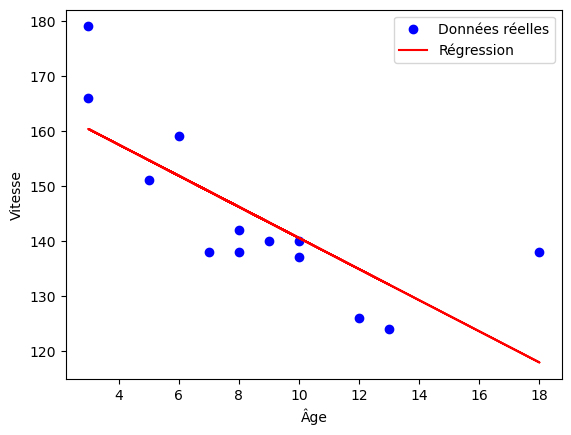

In [ ]:
#parte3==================================================
#solution anylitique
import numpy as np
import matplotlib.pyplot as plt


year = np.array([2018, 2016, 2015, 2016, 2021, 2006, 2021, 2014, 2019, 2012, 2011, 2014, 2017])
speed = np.array([159, 138, 140, 142, 179, 138, 166, 140, 151, 126, 124, 137, 138])

current_year = 2024
x = current_year - year
y = speed


X = np.column_stack([np.ones(len(x)), x])
theta_analytical = np.linalg.inv(X.T @ X) @ X.T @ y

print("Theta analytique:", theta_analytical)


y_pred = X @ theta_analytical

# Graphique
plt.scatter(x, y, color='blue', label='Données réelles')
plt.plot(x, y_pred, color='red', label='Régression')
plt.xlabel('Âge')
plt.ylabel('Vitesse')
plt.legend()
plt.show()

Theta MSE: [ 4.58051512 12.87138425]


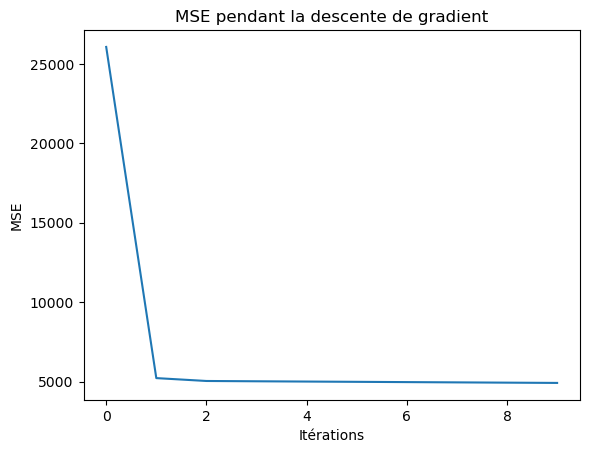

In [64]:
#descente de gradient
def mse_cost(y_true, y_pred):
    return np.mean((y_true - y_pred)**2)

def gradient_descent_mse(X, y, learning_rate=0.01, epochs=10):
    theta = np.random.randn(2)
    m = len(y)
    cost_history = []
    
    for epoch in range(epochs):
        y_pred = X @ theta
        error = y_pred - y
        
        gradient = (X.T @ error) / m
        theta = theta - learning_rate * gradient
        
        cost = mse_cost(y, y_pred)
        
        cost_history.append(cost)
    
    return theta, cost_history

theta_mse, cost_history_mse = gradient_descent_mse(X, y)
print("Theta MSE:", theta_mse)


plt.plot(cost_history_mse)
plt.title('MSE pendant la descente de gradient')
plt.xlabel('Itérations')
plt.ylabel('MSE')
plt.show()

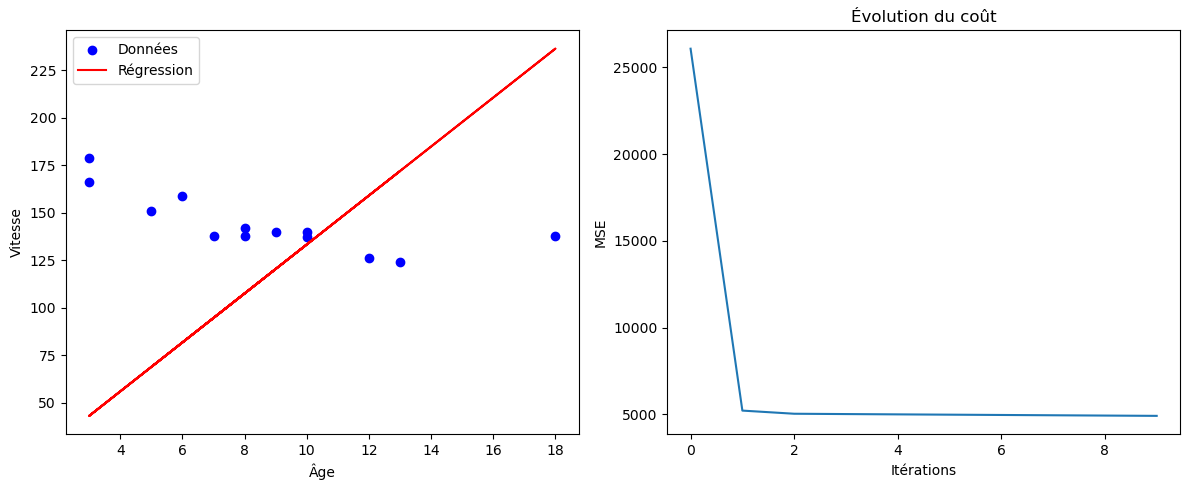

In [65]:
#(Mean Squared Error, MSE)
y_pred_final = X @ theta_mse

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.scatter(x, y, color='blue', label='Données')
plt.plot(x, y_pred_final, color='red', label='Régression')
plt.xlabel('Âge')
plt.ylabel('Vitesse')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(cost_history_mse)
plt.xlabel('Itérations')
plt.ylabel('MSE')
plt.title('Évolution du coût')

plt.tight_layout()
plt.show()

Theta MAE: [-0.36947439  1.40409851]


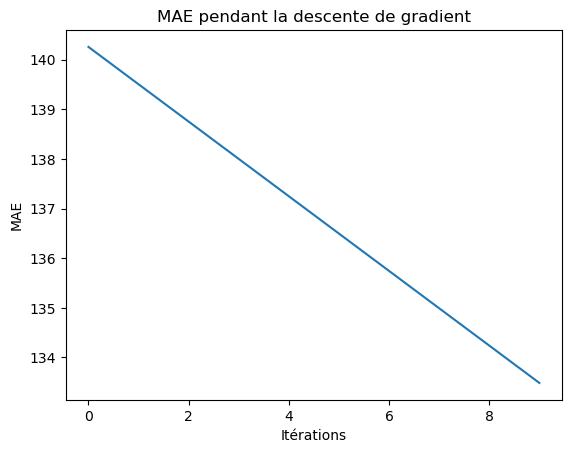

In [48]:
#MAE===========================================================================
def mae_cost(y_true, y_pred):
    return np.mean(np.abs(y_true - y_pred))

def gradient_descent_mae(X, y, learning_rate=0.01, epochs=10):
    theta = np.random.randn(2)
    m = len(y)
    cost_history = []
    
    for epoch in range(epochs):
        y_pred = X @ theta
        error = y_pred - y
        
        gradient = (X.T @ np.sign(error)) / m
        theta = theta - learning_rate * gradient
        
        cost = mae_cost(y, y_pred)
        cost_history.append(cost)
    
    return theta, cost_history

theta_mae, cost_history_mae = gradient_descent_mae(X, y)
print("Theta MAE:", theta_mae)

plt.plot(cost_history_mae)
plt.title('MAE pendant la descente de gradient')
plt.xlabel('Itérations')
plt.ylabel('MAE')
plt.show()

Theta analytique: [168.84326711  -2.83002208]
Theta avec MSE: [ 4.68364191 12.86152666]
Theta avec MAE: [-0.36947439  1.40409851]


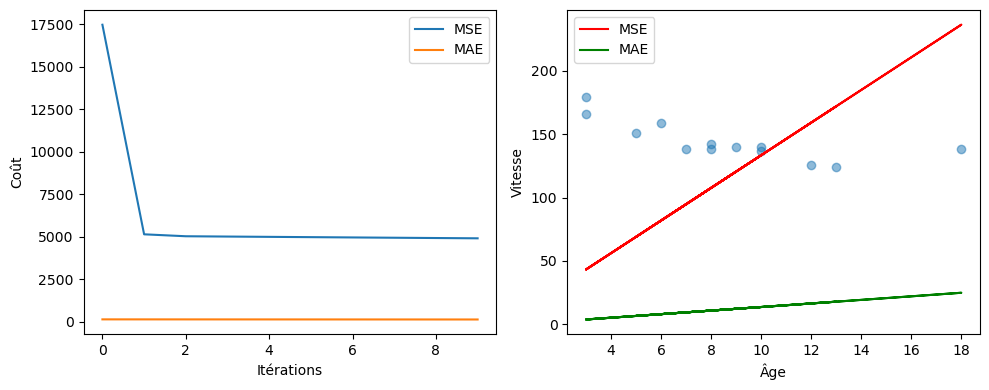

In [49]:
print("Theta analytique:", theta_analytical)
print("Theta avec MSE:", theta_mse)
print("Theta avec MAE:", theta_mae)

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.plot(cost_history_mse, label='MSE')
plt.plot(cost_history_mae, label='MAE')
plt.xlabel('Itérations')
plt.ylabel('Coût')
plt.legend()

plt.subplot(1, 2, 2)
plt.scatter(x, y, alpha=0.5)
plt.plot(x, X @ theta_mse, label='MSE', color='red')
plt.plot(x, X @ theta_mae, label='MAE', color='green')
plt.xlabel('Âge')
plt.ylabel('Vitesse')
plt.legend()

plt.tight_layout()
plt.show()

#prat4=================================


In [70]:
import numpy as np
import matplotlib.pyplot as plt


year = np.array([2018, 2016, 2015, 2016, 2021, 2006, 2021, 2014, 2019, 2012, 2011, 2014, 2017])
speed = np.array([159, 138, 140, 142, 179, 138, 166, 140, 151, 126, 124, 137, 138])
power = np.array([38, 15, 200, 50, 30, 80, 80, 85, 110, 150, 60, 55, 110])

current_year = 2024
x1 = current_year - year 
x2 = power               
y = speed


X = np.column_stack([np.ones(len(x1)), x1, x2])


theta_analytical = np.linalg.inv(X.T @ X) @ X.T @ y

print("Theta analytique:", theta_analytical)
print("Équation: vitesse =", theta_analytical[0], "+", theta_analytical[1], "* âge +", theta_analytical[2], "* puissance")

Theta analytique: [ 1.72540427e+02 -2.70058055e+00 -5.88528065e-02]
Équation: vitesse = 172.5404272620104 + -2.7005805455336787 * âge + -0.05885280649704988 * puissance


In [76]:
#decent gradiante
def gradient_descent_multiple(X, y, learning_rate=0.01, epochs=1000):
    # Normalisation des features (sauf la colonne de 1)
    X_normalized = X.copy()
    X_normalized[:, 1] = (X[:, 1] - np.mean(X[:, 1])) / np.std(X[:, 1])  # Âge
    X_normalized[:, 2] = (X[:, 2] - np.mean(X[:, 2])) / np.std(X[:, 2])  # Puissance
    
    theta = np.random.randn(3) * 0.01
    m = len(y)
    cost_history = []
    
    for epoch in range(epochs):
        y_pred = X_normalized @ theta
        error = y_pred - y
        
        gradient = (X_normalized.T @ error) / m
        theta = theta - learning_rate * gradient
        
        cost = np.mean((y_pred - y)**2)
        cost_history.append(cost)
        
        if epoch % 200 == 0:
            print(f"Epoch {epoch}, Cost: {cost:.2f}")
    
    return theta, cost_history

theta_gd, cost_history = gradient_descent_multiple(X, y)
print("Theta descente de gradient:", theta_gd)

Epoch 0, Cost: 21095.00
Epoch 200, Cost: 462.52
Epoch 400, Cost: 92.70
Epoch 600, Cost: 86.06
Epoch 800, Cost: 85.94
Theta descente de gradient: [144.4553014  -10.82916023  -2.89793105]


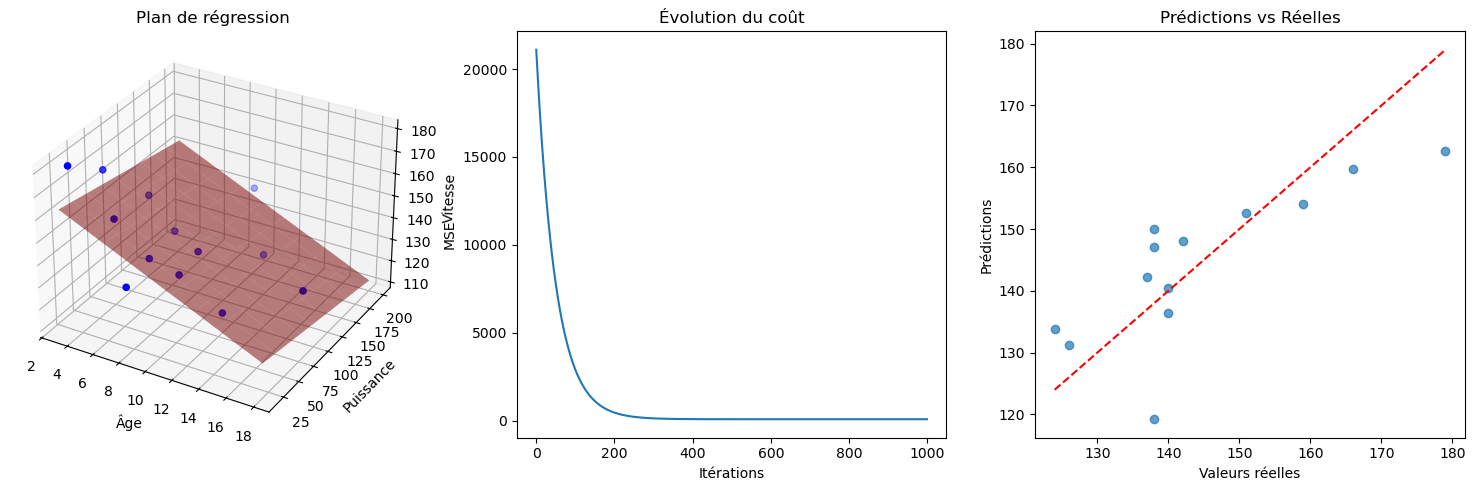

In [77]:
from mpl_toolkits.mplot3d import Axes3D

# Graphique 3D
fig = plt.figure(figsize=(15, 5))

# Plan de régression
ax1 = fig.add_subplot(131, projection='3d')
ax1.scatter(x1, x2, y, color='blue', label='Données')

# Créer le plan
x1_range = np.linspace(min(x1), max(x1), 10)
x2_range = np.linspace(min(x2), max(x2), 10)
X1, X2 = np.meshgrid(x1_range, x2_range)
Y_plane = theta_analytical[0] + theta_analytical[1]*X1 + theta_analytical[2]*X2

ax1.plot_surface(X1, X2, Y_plane, alpha=0.5, color='red')
ax1.set_xlabel('Âge')
ax1.set_ylabel('Puissance')
ax1.set_zlabel('Vitesse')
ax1.set_title('Plan de régression')

# Courbe de coût
ax2 = fig.add_subplot(132)
ax2.plot(cost_history)
ax2.set_xlabel('Itérations')
ax2.set_ylabel('MSE')
ax2.set_title('Évolution du coût')

# Prédictions vs Réelles
ax3 = fig.add_subplot(133)
y_pred = X @ theta_analytical
ax3.scatter(y, y_pred, alpha=0.7)
ax3.plot([min(y), max(y)], [min(y), max(y)], color='red', linestyle='--')
ax3.set_xlabel('Valeurs réelles')
ax3.set_ylabel('Prédictions')
ax3.set_title('Prédictions vs Réelles')

plt.tight_layout()
plt.show()